In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data"
DATA_PATH

PosixPath('/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/data')

In [2]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from PIL import Image
import numpy as np

from src.model_training_pipeline import TripletSiameseModel  
from src.dataset import TripletSignatureDataset  # your dataset

DEVICE = "mps" if torch.mps.is_available() else "cpu"

In [3]:
# ----------------------------
# CONFIG
# ----------------------------
MODEL_PATH = "train_logs/siamese_signature/version_10/checkpoints/epoch=22-step=3588.ckpt"
BATCH_SIZE = 1
NUM_TO_VISUALIZE = 10
IMAGE_SIZE = 224
DATA_PATH = PROJECT_ROOT / "data"
DATA_PATH

PosixPath('/Users/srijanshovit/Documents/Coding/SignatureVerificationSiamese/data')

In [4]:
# ----------------------------
# TRANSFORMS
# ----------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [5]:
# ----------------------------
# MODEL LOADING
# ----------------------------
def load_model(model_path):
    model = TripletSiameseModel.load_from_checkpoint(embedding_dim=256,checkpoint_path=model_path)
    model.eval()
    model.to(DEVICE)
    return model

In [6]:
from src.datamodule import TripletDataModule


dm = TripletDataModule(
    data_dir=DATA_PATH,
    batch_size=64,
    num_workers=4,
    image_size=128,
    pin_memory=False,
    test_transformations=transform
)

# Setup datasets (fit stage)
dm.setup(stage="test")

In [7]:
print(
    "Train:", len(getattr(dm, "train_dataset", [])),
    "Val:", len(getattr(dm, "val_dataset", [])),
    "Test:", len(getattr(dm, "test_dataset", []))
)

Train: 0 Val: 0 Test: 10000



===== TEST TRIPLET SANITY CHECK =====
anchor shape: torch.Size([64, 3, 224, 224])
positive shape: torch.Size([64, 3, 224, 224])
negative shape: torch.Size([64, 3, 224, 224])
dtype: torch.float32
test triplet sanity passed.


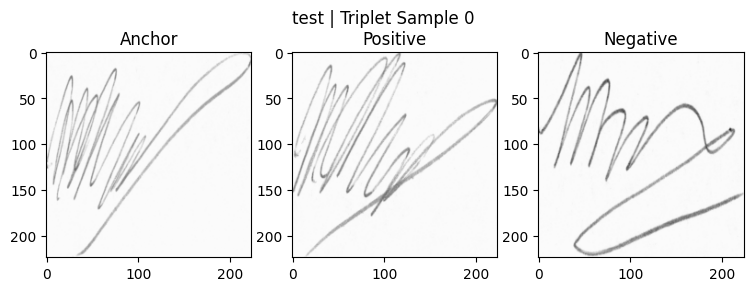

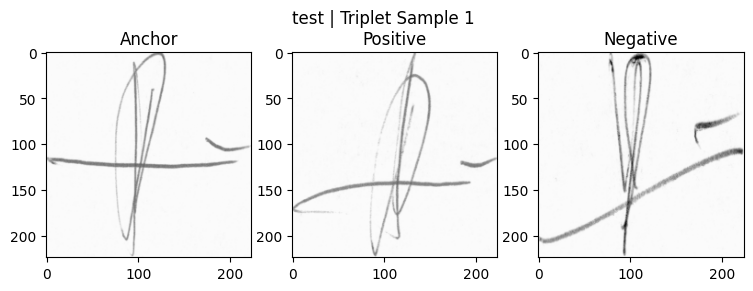

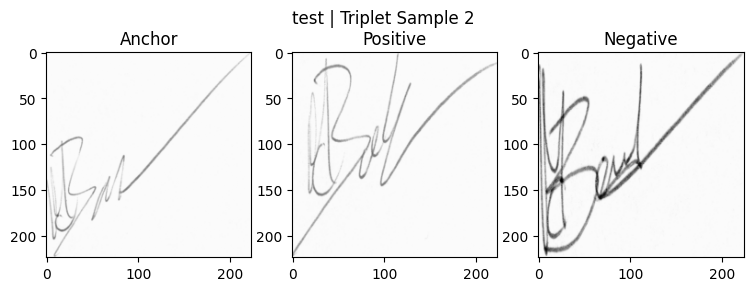

In [8]:
from src.dataloader_utils import sanity_check_triplet_loader


sanity_check_triplet_loader(loader=dm.test_dataloader(),split_name="test")


In [9]:
from pytorch_grad_cam import GradCAM
model = load_model(model_path=MODEL_PATH)
model

TripletSiameseModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [10]:
import torch.nn as nn

class EmbeddingWrapper(nn.Module):
    def __init__(self, siamese_model):
        super().__init__()
        self.model = siamese_model

    def forward(self, x):
        return self.model.forward_once(x)
    

wrapped_model = EmbeddingWrapper(model).to(DEVICE)
wrapped_model.eval()

target_layer = wrapped_model.model.backbone[7][1].conv2

In [11]:
# Grad-CAM on last conv layer
cam = GradCAM(model=wrapped_model, target_layers=[target_layer])

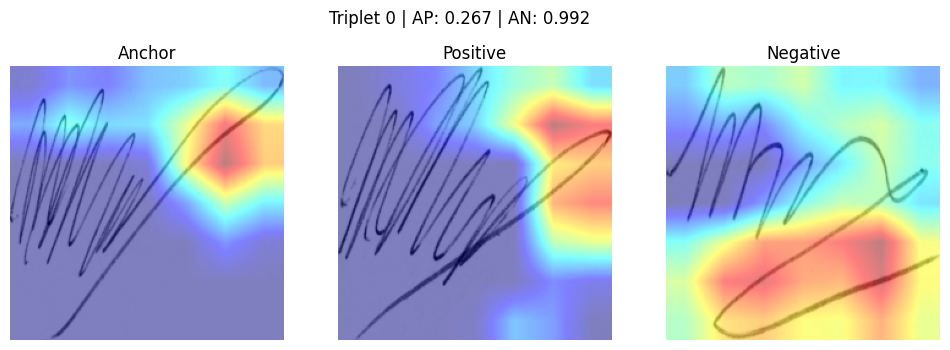

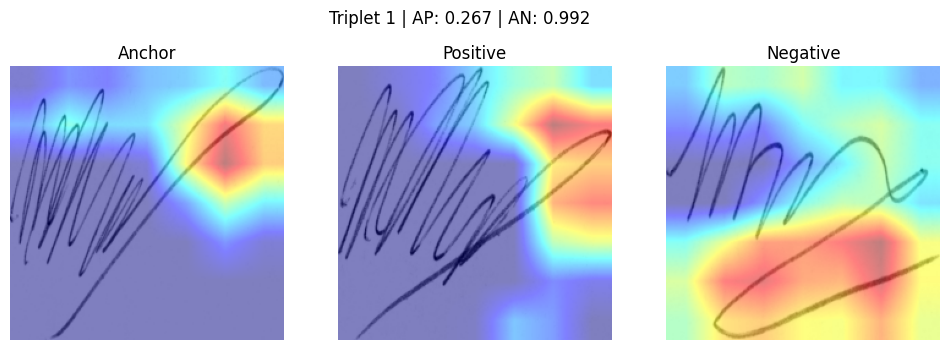

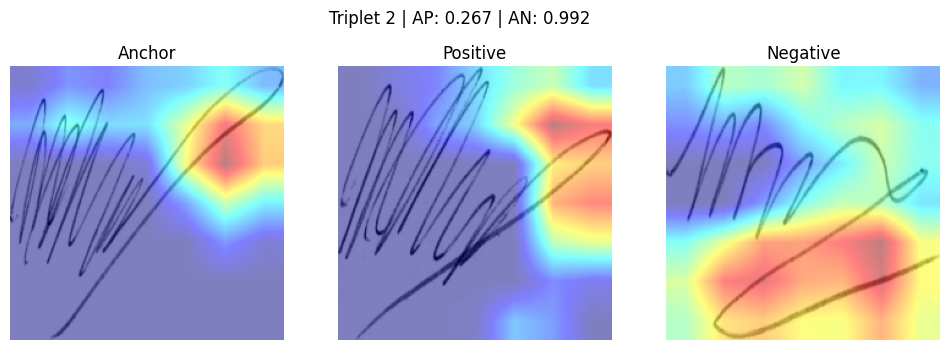

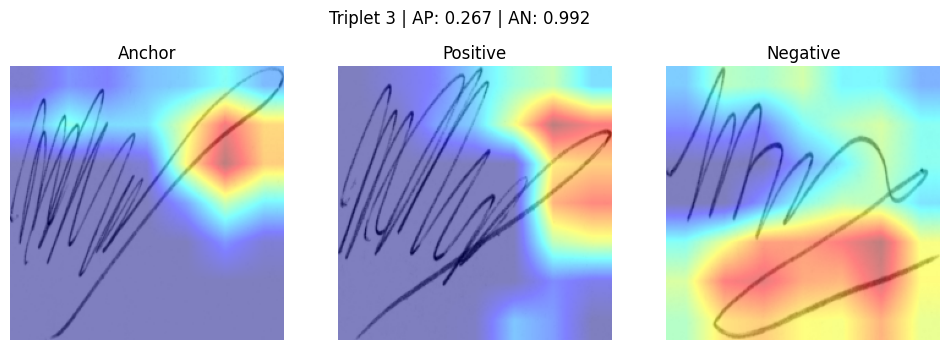

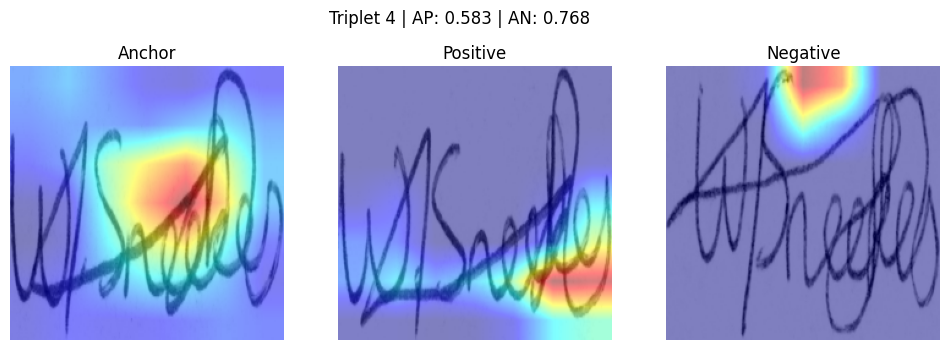

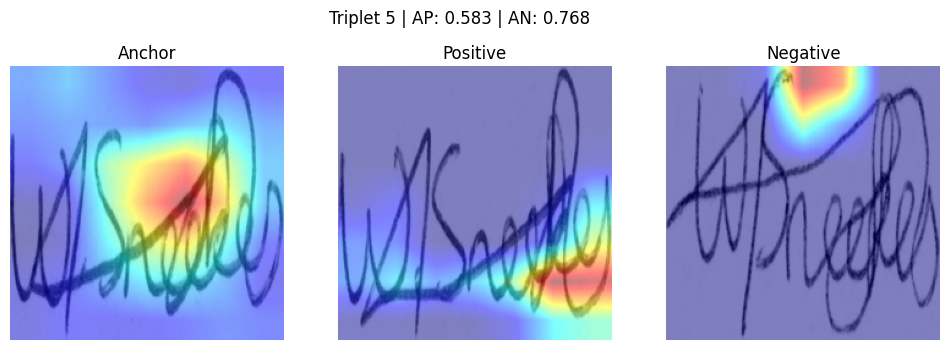

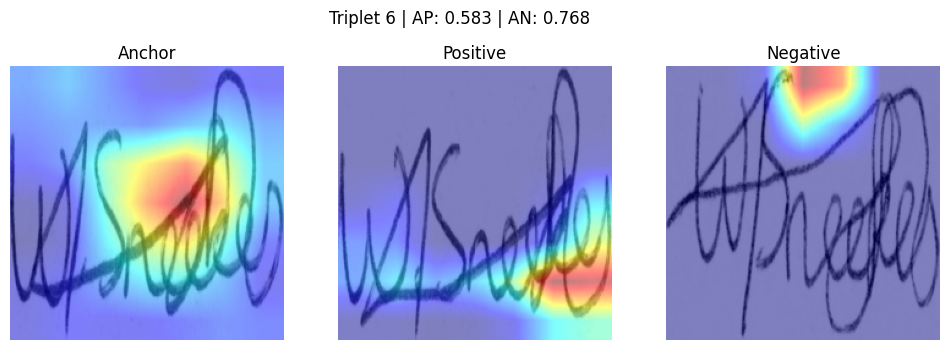

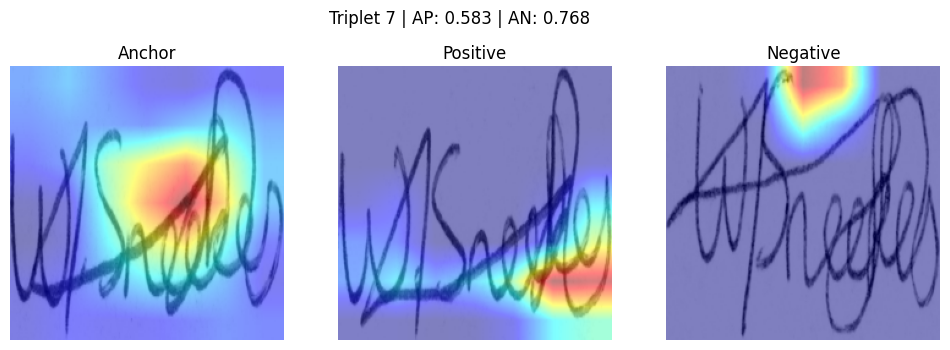

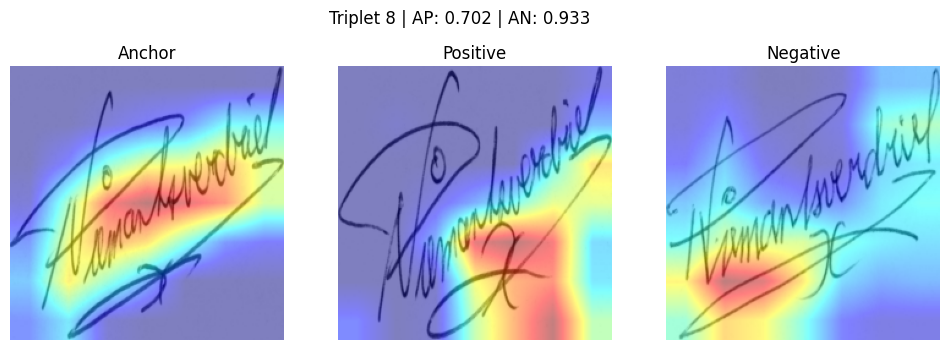

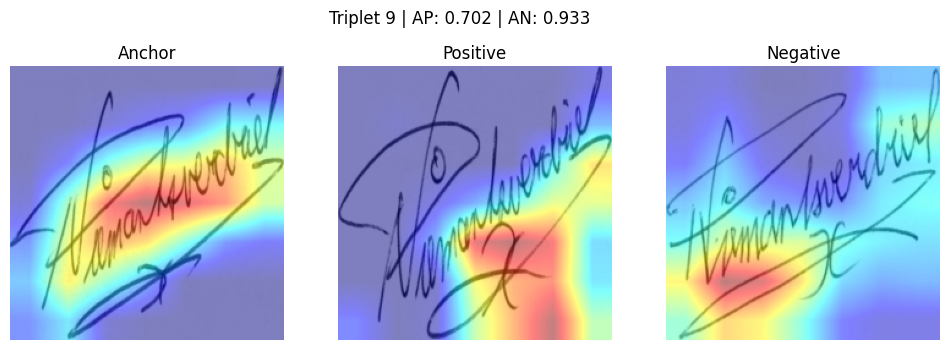

In [12]:
# Visualize triplets
from src.inference_utils import visualize_triplet


for idx, (anchor, positive, negative) in enumerate(dm.test_dataloader()):
    if idx >= NUM_TO_VISUALIZE:
        break
    visualize_triplet(DEVICE,model, (anchor, positive, negative), cam, idx)


**Grad-CAM Visualization (Siamese Signature Model)**

* Grad-CAM is used to visualize which regions of a signature image most influence the embedding produced by the CNN backbone.
* Heatmaps are generated for **anchor, positive, and negative** samples from triplets in the test set.
* Red regions indicate areas that contribute strongly to the feature representation used for similarity comparison.
* Comparing anchor–positive vs anchor–negative heatmaps helps inspect whether the model focuses on **consistent signature strokes** for genuine pairs.
* This visualization is primarily used for **model debugging and interpretability**, not as a quantitative evaluation metric.
